<a href="https://colab.research.google.com/github/sinethdilhara2002/ET3112_Assignment_02/blob/main/a02%200153.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving 1 c.png to 1 c.png


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression

In [3]:
image_path = "1 c.png"

Image shape: (142, 122)


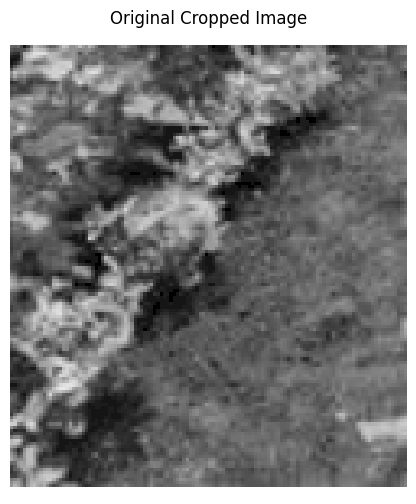

In [4]:
image_path = "1 c.png"   # change this to your uploaded file name

img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not loaded. Check the filename.")

print("Image shape:", img.shape)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title("Original Cropped Image")
plt.axis('off')
plt.show()

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
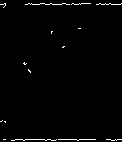

In [5]:
cv.Canny(img, 550, 690)

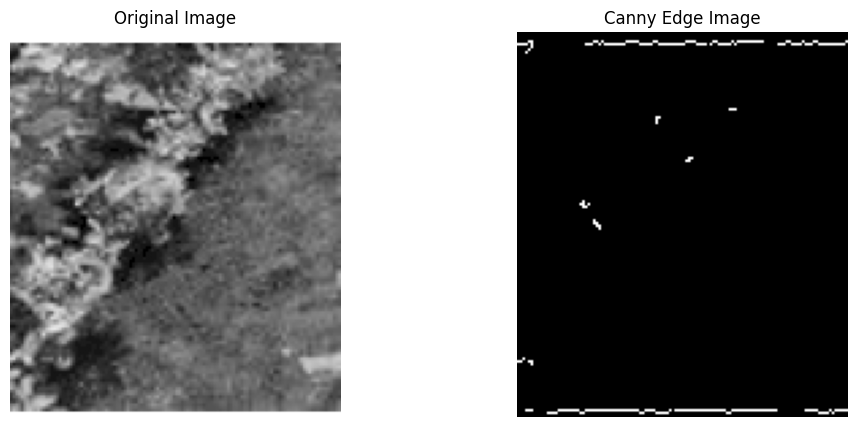

In [6]:
edges = cv.Canny(img, 550, 690)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Image")
plt.axis('off')

plt.show()

In [7]:
indices = np.where(edges != 0)
x = indices[1]
y = indices[0]

print("Number of edge points:", len(x))

Number of edge points: 233


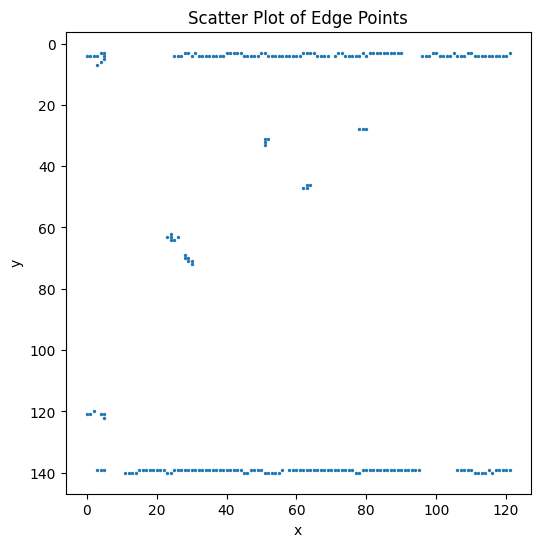

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)
plt.gca().invert_yaxis()   # image coordinates
plt.title("Scatter Plot of Edge Points")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [9]:
m_ls, c_ls = np.polyfit(x, y, 1)

print("Least Squares Slope (m):", m_ls)
print("Least Squares Intercept (c):", c_ls)

Least Squares Slope (m): -0.17216792325569125
Least Squares Intercept (c): 81.66331164980804


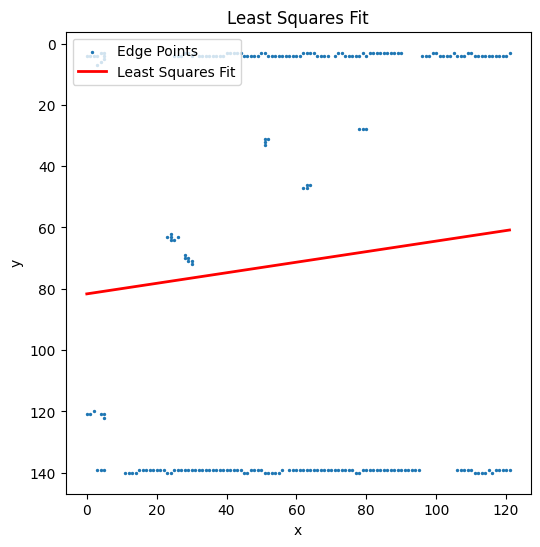

In [10]:
x_line = np.linspace(np.min(x), np.max(x), 500)
y_line_ls = m_ls * x_line + c_ls

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2, label='Edge Points')
plt.plot(x_line, y_line_ls, 'r', linewidth=2, label='Least Squares Fit')
plt.gca().invert_yaxis()
plt.title("Least Squares Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [11]:
theta_ls_rad = np.arctan(m_ls)
theta_ls_deg = np.degrees(theta_ls_rad)

print("Least Squares Angle (degrees):", theta_ls_deg)

Least Squares Angle (degrees): -9.768725841643867


In [12]:
print("Least Squares Angle Magnitude:", abs(theta_ls_deg))

Least Squares Angle Magnitude: 9.768725841643867


In [13]:
points = np.column_stack((x, y))
centroid = np.mean(points, axis=0)

X = points - centroid
U, S, Vt = np.linalg.svd(X)

direction = Vt[0]
dx, dy = direction[0], direction[1]

print("TLS direction vector:", direction)

TLS direction vector: [-0.06452152  0.99791632]


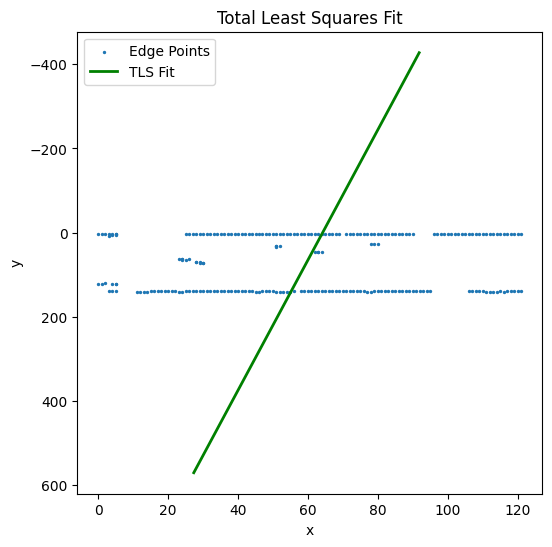

In [14]:
t = np.linspace(-500, 500, 500)
x_tls = centroid[0] + t * dx
y_tls = centroid[1] + t * dy

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2, label='Edge Points')
plt.plot(x_tls, y_tls, 'g', linewidth=2, label='TLS Fit')
plt.gca().invert_yaxis()
plt.title("Total Least Squares Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [15]:
theta_tls_rad = np.arctan2(dy, dx)
theta_tls_deg = np.degrees(theta_tls_rad)

print("TLS Angle (degrees):", theta_tls_deg)
print("TLS Angle Magnitude:", abs(theta_tls_deg))

TLS Angle (degrees): 93.69938082878178
TLS Angle Magnitude: 93.69938082878178


In [16]:
lines = cv.HoughLines(edges, 1, np.pi/180, 60)

if lines is None:
    print("No lines detected. Try reducing the threshold.")
else:
    print("Number of detected lines:", len(lines))
    rho, theta = lines[0][0]
    print("Best line rho:", rho)
    print("Best line theta (radians):", theta)
    print("Best line theta (degrees):", np.degrees(theta))

Number of detected lines: 2
Best line rho: 139.0
Best line theta (radians): 1.5707964
Best line theta (degrees): 90.0


In [19]:
theta_hough_deg = np.degrees(theta)
line_angle_deg = theta_hough_deg - 90

print("Hough parameter theta (deg):", theta_hough_deg)
print("Estimated crop slope angle (deg):", line_angle_deg)
print("Estimated crop slope angle magnitude:", abs(line_angle_deg))

Hough parameter theta (deg): 90.0
Estimated crop slope angle (deg): 0.0
Estimated crop slope angle magnitude: 0.0


In [22]:
slope_tls = dy / dx

In [23]:
angle_tls_rad = np.arctan(slope_tls)
angle_tls_deg = np.degrees(angle_tls_rad)
positive_magnitude_tls = abs(angle_tls_deg)

In [24]:
print("--- Answer for Question 07 ---")
print(f"Calculated TLS Slope (m): {slope_tls:.4f}")
print(f"Estimated Crop Field Angle (Original): {angle_tls_deg:.2f} degrees")
print(f"Estimated Crop Field Angle (Absolute Value): {positive_magnitude_tls:.2f} degrees")

--- Answer for Question 07 ---
Calculated TLS Slope (m): -15.4664
Estimated Crop Field Angle (Original): -86.30 degrees
Estimated Crop Field Angle (Absolute Value): 86.30 degrees


In [25]:
slope_tls
angle_tls_deg

np.float64(-86.30061917121823)

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression

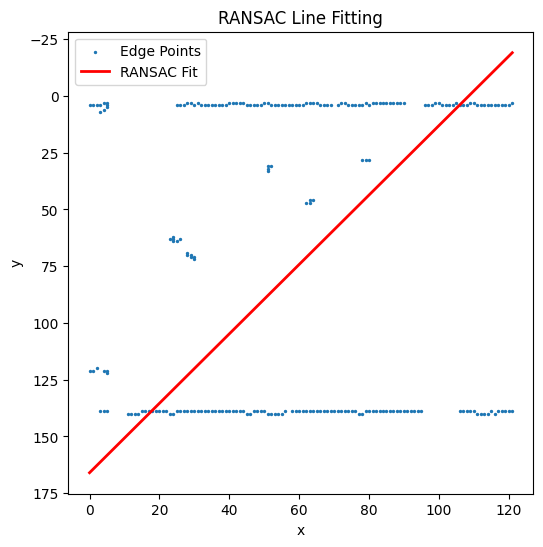

In [27]:

X = x.reshape(-1, 1)
Y = y

ransac = RANSACRegressor(LinearRegression(), random_state=0)
ransac.fit(X, Y)

x_line = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)
y_ransac = ransac.predict(x_line)

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2, label='Edge Points')
plt.plot(x_line, y_ransac, 'r', linewidth=2, label='RANSAC Fit')
plt.gca().invert_yaxis()
plt.xlabel('x')
plt.ylabel('y')
plt.title('RANSAC Line Fitting')
plt.legend()
plt.show()

In [28]:
slope_ransac = ransac.estimator_.coef_[0]
intercept_ransac = ransac.estimator_.intercept_

angle_ransac = np.degrees(np.arctan(slope_ransac))
positive_angle_ransac = abs(angle_ransac)

print("--- Answer for Question 10 / 11 ---")
print(f"Calculated RANSAC Slope (m): {slope_ransac:.4f}")
print(f"Intercept (c): {intercept_ransac:.4f}")
print(f"Estimated Crop Field Angle (Original): {angle_ransac:.2f} degrees")
print(f"Estimated Crop Field Angle (Absolute Value): {positive_angle_ransac:.2f} degrees")

--- Answer for Question 10 / 11 ---
Calculated RANSAC Slope (m): -1.5293
Intercept (c): 165.9932
Estimated Crop Field Angle (Original): -56.82 degrees
Estimated Crop Field Angle (Absolute Value): 56.82 degrees
